In [7]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,BB_SMA,BB_STD,Upper_Band,Lower_Band,Strategy,Asset_Returns,Strategy_Returns
Date,,,,,,,,,,,,
1993-02-26,24.500034,24.517276,24.379345,24.517276,66200,24.426753,0.311848,25.050449,23.803057,0,NaN,NaN
1993-03-01,24.431057,24.586230,24.396574,24.586230,66500,24.436236,0.308784,25.053804,23.818668,0,-0.002815,0.000000
1993-03-02,24.793125,24.793125,24.413814,24.448297,182400,24.455200,0.318820,25.092840,23.817560,0,0.011963,0.000000
1993-03-03,24.896570,24.913812,24.793122,24.827605,280100,24.476752,0.333773,25.144299,23.809205,0,0.016185,0.000000
1993-03-04,24.758650,24.931064,24.758650,24.931064,89500,24.478476,0.335205,25.148885,23.808066,0,0.010556,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-05,681.309998,685.530029,675.609985,682.080017,106606500,686.183499,4.721201,695.625901,676.741098,0,26.808532,23356.481638
2026-03-06,672.380005,676.109985,669.760010,673.409973,100687000,685.921500,5.327856,696.577212,675.265787,-1,26.444043,23662.630294
2026-03-09,678.270020,679.919983,662.390015,666.390015,102667700,685.304001,5.468465,696.240932,674.367070,0,26.684452,23662.630294


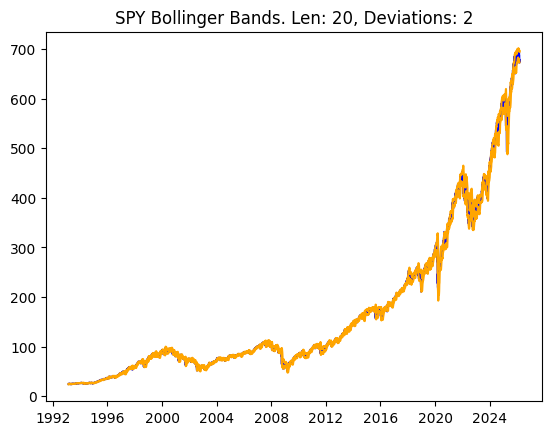

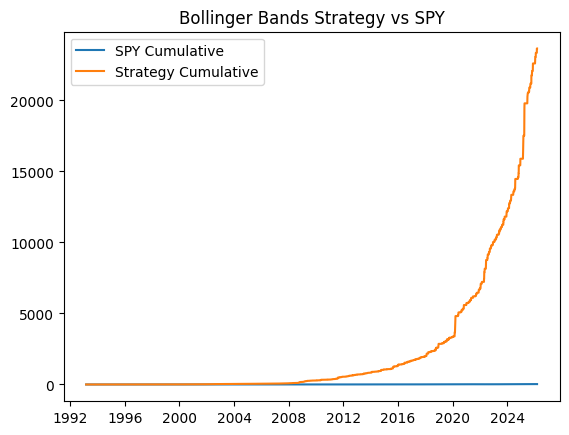

In [ ]:
TICKER = 'SPY'
BB_LEN = 20
DEVS = 2
LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK):
    df = yf.download(ticker)
    df.columns = df.columns.get_level_values(0)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

def add_bollinger_bands(df, devs=DEVS, bb_len=BB_LEN):

    # can change to ema (use MACD video/code for reference)
    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    # get the standard deviation of the close prices for the period
    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df

def add_strategy(df):
    df['Strategy'] = 0
    df['Strategy'] = np.where(
        df['Close'] > df['Upper_Band'], 1, 
        np.where(df['Close'] < df['Lower_Band'], -1, 0)
        )
    
    df['Strategy'] = df['Strategy'].shift(1)
    
    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1

    # plot the strategy returns
    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.title(F'Bollinger Bands Strategy vs {TICKER}');

    return df


def main():
    df = get_data()
    df = add_bollinger_bands(df)
    df = add_strategy(df)
    df = test_strategy(df)

    return df

df = main()

df